In [6]:
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 7)
%matplotlib inline

In [7]:
with open('dataset_linkedin.json', encoding='utf-8') as f:
    datos = json.load(f)

df = pd.DataFrame(datos)
print(f"Ofertas cargadas: {len(df)}")
print(f"Columnas disponibles: {list(df.columns)}")

Ofertas cargadas: 430
Columnas disponibles: ['id', 'trackingId', 'refId', 'link', 'title', 'companyName', 'companyLinkedinUrl', 'companyLogo', 'location', 'postedAt', 'benefits', 'descriptionHtml', 'applicantsCount', 'applyUrl', 'salary', 'descriptionText', 'seniorityLevel', 'employmentType', 'jobFunction', 'industries', 'inputUrl', 'salaryInsights', 'applyMethod', 'expireAt', 'postedAtTimestamp', 'workplaceTypes', 'workRemoteAllowed', 'standardizedTitle', 'country', 'companyAddress', 'companyWebsite', 'companySlogan', 'companyDescription', 'companyEmployeesCount', 'jobPosterName', 'jobPosterTitle', 'jobPosterPhoto', 'jobPosterProfileUrl']


In [8]:
# Ver cómo luce una oferta completa
print(datos[0]['title'])
print(datos[0]['companyName'])
print(datos[0]['descriptionText'][:500])  # primeros 500 caracteres


Conserje  area de limpieza para funeraria.
VANGRUPO
Plaza: Conserje

Funciones Principales

Realizar limpieza general de oficinas, áreas comunes y baños

Mantener el orden y la higiene de las instalaciones

Apoyo en actividades básicas de mantenimiento

Manejo adecuado de insumos de limpieza

Reportar cualquier desperfecto o necesidad en las áreas asignadas

Requisitos

Experiencia previa en labores de limpieza

Persona responsable, puntual y ordenada

Buena actitud y disposición para el trabajo en equipo

Atención al detalle

Disponibilidad inme


In [9]:
#Limpieza 
df['texto'] = (
    df['descriptionText'].fillna('') + ' ' + 
    df['title'].fillna('')
).str.lower()

In [80]:
HABILIDADES = {
    "Excel / Hojas de cálculo": [
        "excel", "hojas de cálculo", "google sheets", "spreadsheet"
    ],
    "SQL / Bases de datos": [
        "sql", "mysql", "postgresql", "oracle", "base de datos", "database"
    ],
    "Power BI / Tableau": [
        "power bi", "tableau", "looker", "dashboard", "data visualization"
    ],
    "Python / Programación": [
        "python", "programación", "programacion", "desarrollo de software",
        "software development", "programming", "developer"
    ],
    "Análisis de datos": [
        "análisis de datos", "analítica", "analisis de datos", "analitica",
        "analytics", "data analysis", "business intelligence", "data analyst",
        "data science", "ciencia de datos"
    ],
    "Inteligencia Artificial / IA": [
        "inteligencia artificial", "machine learning", "automatización", "rpa",
        " ia ", " ai ", "chatgpt", "claude", "artificial intelligence",
        "deep learning", "nlp", "large language model"
    ],
    "SAP / ERP": [
        " sap ", " erp ", "sistemas de gestión", "sistemas de gestion",
        "enterprise resource planning"
    ],
    "Office / Paquete Microsoft": [
        "microsoft office", "paquete office", "word", "powerpoint",
        "ms office", "office 365", "microsoft 365", "outlook", "office", "microsoft"
    ],
    "Contabilidad / Finanzas": [
        "contabilidad", "finanzas", "financiero", "estados financieros",
        "accounting", "finance", "financial", "bookkeeping", "auditoría", "auditoria"
    ],
    "Ventas / CRM": [
        "ventas", " crm ", "salesforce", "comercial", "hubspot",
        "sales", "business development", "account management"
    ],
    "Logística / Supply Chain": [
        "logística", "logistica", "supply chain", "inventario", "almacén",
        "bodega", "suministro", "warehouse", "inventory", "procurement"
    ],
    "Marketing Digital": [
        "marketing digital", "redes sociales", " seo ", "google ads",
        "community manager", "instagram", "tiktok", "digital marketing",
        "social media", "content marketing", "email marketing"
    ],
    "Gestión de proyectos": [
        "gestión de proyectos", "project management", "scrum", "agile", "kanban", "jira", " pmp ",  "project manager",
    "gerencia de proyectos", "coordinación de proyectos", "coordinacion de proyectos"
    ],
    "Inglés": [
        "inglés", "english", "bilingüe", "bilingual", "ingles",
        "inglés avanzado", "english proficiency", "fluent in english"
    ],
    "Liderazgo": [
        "liderazgo", "líder", "gestión de equipos", "supervisor", "lider",
        "leadership", "team management", "people management", "team leader"
    ],
    "Trabajo en equipo": [
        "trabajo en equipo", "teamwork", "colaboración", "colaboracion",
        "team player", "cross-functional", "collaborative", "relaciones interpersonales"
    ],
    "Comunicación": [
        "comunicación", "comunicación efectiva", "comunicación asertiva",
        "comunicacion", "comunicacion efectiva", "comunicacion asertiva",
        "comunicación oral y escrita", "comunicacion oral y escrita",
        "comunicación escrita", "comunicacion escrita",
        "communication", "communication skills", "written communication",
        "verbal communication", "presentation skills"
    ],
    "Orientación al cliente": [
        "atención al cliente", "servicio al cliente", "customer service",
        "atencion al cliente", "customer success", "client relations",
        "customer experience", "cx"
    ],
    "Resolución de problemas": [
        "resolución de problemas", "pensamiento analítico", "toma de decisiones",
        "resolucion de problemas", "pensamiento analitico",
        "resolución de conflictos", "pensamiento crítico",
        "resolucion de conflictos", "pensamiento critico",
        "problem solving", "critical thinking", "decision making",
        "analytical thinking", "conflict resolution"
    ],
    "Proactividad / Iniciativa": [
        "proactivo", "proactiva", "proactividad", "iniciativa", "autónomo",
        "self-motivated", "self-starter", "proactive", "autonomous"
    ],
    "Licenciatura / Universidad": [
        # Genérico español
        "licenciatura", "universitario", "universitaria",
        "graduado", "graduada", "título", "titulo",
        "carrera universitaria", "carrera afín", "carrera afin",
        "carrera relacionada", "profesional universitario", "profesional universitaria",
        # Genérico inglés
        "bachelor", "degree", "bachelor's degree", "university degree",
        "undergraduate", "college degree", "higher education",
        # Ingeniería
        "ingeniería", "ingenieria", "ingeniero", "ingeniera",
        "engineering", "engineer",
        # Licenciados por área
        "licenciado", "licenciada",
        # Administración
        "administrador", "administradora",
        "administración de empresas", "administracion de empresas",
        "business administration", "business management",
        # Contabilidad
        "contador", "contadora", "accounting degree", "cpa",
        # Mercadeo
        "mercadólogo", "mercadologa", "mercadologo",
        "marketing degree",
        # Psicología
        "psicólogo", "psicóloga", "psicologo", "psicologa",
        "psicología", "psicologia", "psychology degree",
        # Derecho
        "abogado", "abogada", "derecho", "law degree",
        # Economía
        "economista", "economía", "economia", "economics degree",
        # Comunicaciones
        "comunicador", "comunicadora", "comunicaciones",
        "communications degree",
        # Educación
        "educador", "educadora", "pedagogía", "pedagogia",
        "education degree",
        # Medicina / Salud
        "médico", "medico", "médica", "enfermero", "enfermera",
        "medicine", "nursing degree",
        # Arquitectura
        "arquitecto", "arquitecta", "arquitectura",
        "architecture degree",
        # Tecnología
        "técnico", "tecnico", "técnica", "tecnica",
        "technical degree",
    ],
    "Maestría / Posgrado": [
        "maestría", " mba ", "posgrado", "master", "maestria",
        "master's degree", "postgraduate", "graduate degree"
    ],
    "Experiencia requerida": [
        "años de experiencia", "experiencia mínima", "experiencia comprobada",
        "experiencia", "years of experience", "experience required",
        "proven experience", "work experience", "professional experience"
    ],
}

print(f"Habilidades a detectar: {len(HABILIDADES)}")
print(f"Habilidades a detectar: {len(HABILIDADES)}")

Habilidades a detectar: 23
Habilidades a detectar: 23


In [81]:
def extraer_habilidades(texto):
    encontradas = []
    for habilidad, palabras in HABILIDADES.items():
        for palabra in palabras:
            if palabra in texto:
                encontradas.append(habilidad)
                break
    return encontradas

In [82]:
df['habilidades'] = df['texto'].apply(extraer_habilidades)
df['num_habilidades'] = df['habilidades'].apply(len)

print(f"Ofertas con al menos 1 habilidad detectada: {(df['num_habilidades'] > 0).sum()}")
print(f"\nEjemplo — oferta 1:")
print(f"Puesto: {df['title'][0]}")
print(f"Habilidades: {df['habilidades'][0]}")

Ofertas con al menos 1 habilidad detectada: 422

Ejemplo — oferta 1:
Puesto: Conserje  area de limpieza para funeraria.
Habilidades: ['Trabajo en equipo', 'Experiencia requerida']


In [83]:
df['habilidades']

0             [Trabajo en equipo, Experiencia requerida]
1      [Excel / Hojas de cálculo, Office / Paquete Mi...
2      [Logística / Supply Chain, Liderazgo, Experien...
3                            [Proactividad / Iniciativa]
4      [Logística / Supply Chain, Experiencia requerida]
                             ...                        
425    [Excel / Hojas de cálculo, Python / Programaci...
426    [Excel / Hojas de cálculo, SQL / Bases de dato...
427    [Contabilidad / Finanzas, Inglés, Comunicación...
428                           [Logística / Supply Chain]
429    [Excel / Hojas de cálculo, SQL / Bases de dato...
Name: habilidades, Length: 430, dtype: object

In [84]:
contador = Counter()
for habilidades in df['habilidades']:
    for habilidad in habilidades:
        contador[habilidad] += 1

total = len(df)
print(f"Total de ofertas: {total}\n")
print("Top 10 habilidades más demandadas:")
for habilidad, frecuencia in contador.most_common(10):
    porcentaje = frecuencia / total * 100
    print(f"  {habilidad}: {frecuencia} ofertas ({porcentaje:.1f}%)")

Total de ofertas: 430

Top 10 habilidades más demandadas:
  Experiencia requerida: 327 ofertas (76.0%)
  Licenciatura / Universidad: 242 ofertas (56.3%)
  Excel / Hojas de cálculo: 197 ofertas (45.8%)
  Comunicación: 136 ofertas (31.6%)
  Ventas / CRM: 135 ofertas (31.4%)
  Logística / Supply Chain: 98 ofertas (22.8%)
  Liderazgo: 94 ofertas (21.9%)
  Orientación al cliente: 90 ofertas (20.9%)
  Proactividad / Iniciativa: 86 ofertas (20.0%)
  Contabilidad / Finanzas: 75 ofertas (17.4%)


In [85]:
df_freq = pd.DataFrame([
    {
        "Habilidad": habilidad,
        "Frecuencia": frecuencia,
        "Porcentaje": round(frecuencia / total * 100, 1)
    }
    for habilidad, frecuencia in contador.most_common()
])

In [86]:
df_freq

,Habilidad,Frecuencia,Porcentaje
0,Experiencia requerida,327,76.0
1,Licenciatura / Universidad,242,56.3
2,Excel / Hojas de cálculo,197,45.8
3,Comunicación,136,31.6
4,Ventas / CRM,135,31.4
5,Logística / Supply Chain,98,22.8
6,Liderazgo,94,21.9
7,Orientación al cliente,90,20.9
8,Proactividad / Iniciativa,86,20.0
9,Contabilidad / Finanzas,75,17.4


In [87]:
# Ofertas que NO mencionan licenciatura NI experiencia requerida
sin_requisitos = df[
    df['habilidades'].apply(lambda x: 
        'Licenciatura / Universidad' not in x and 
        'Experiencia requerida' not in x
    )
]

print(f"Ofertas sin título ni experiencia requerida: {len(sin_requisitos)}")
print("\nEjemplos:")
for i, row in sin_requisitos.head(10).iterrows():
    print(f"\nPuesto: {row['title']}")
    print(f"Empresa: {row['companyName']}")
    print(f"Habilidades detectadas: {row['habilidades']}")
    print(f"Descripción (primeros 300 caracteres):")
    print(row['descriptionText'])
    print("-"*60)

Ofertas sin título ni experiencia requerida: 68

Ejemplos:

Puesto: Recepcionista
Empresa: GRUPO CENTRA SA DE CV
Habilidades detectadas: ['Excel / Hojas de cálculo', 'Office / Paquete Microsoft', 'Comunicación', 'Orientación al cliente', 'Proactividad / Iniciativa']
Descripción (primeros 300 caracteres):
Buscamos una Recepcionista para unirse a nuestro equipo de trabajo. Si eres una persona organizada, proactiva y con excelente actitud de servicio, ¡esta oportunidad es para ti!

¿Qué buscamos?

Excelente presentación y atención al cliente.Habilidades organizativas y gestión de documentos.Dominio de herramientas de oficina (Word, Excel, correo electrónico).Comunicación asertiva y fluidez verbal.

Principales Funciones

Recepción y atención de visitas/clientes.Gestión de llamadas y correspondencia.Apoyo administrativo.
------------------------------------------------------------

Puesto: CAIXA
Empresa: ZEMA
Habilidades detectadas: ['Proactividad / Iniciativa']
Descripción (primeros 300 c

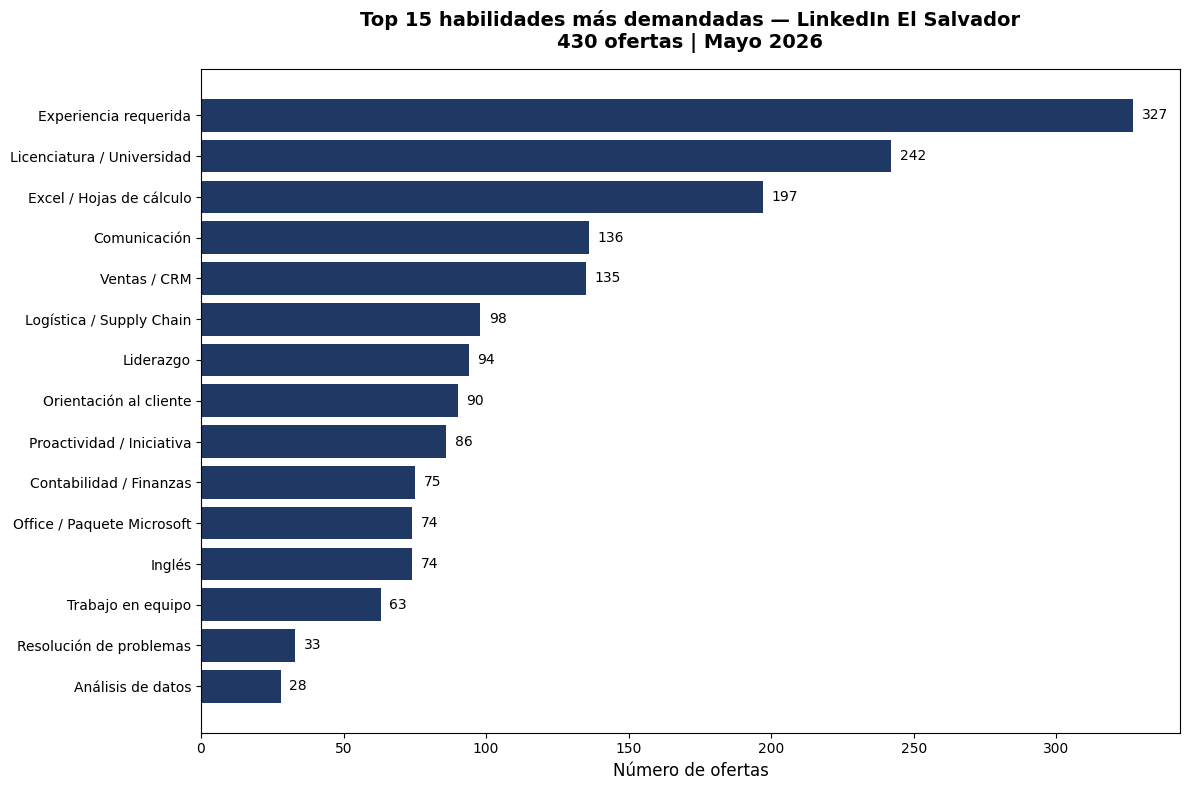

Gráfico guardado como top15_habilidades.png


In [88]:
top15 = df_freq.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(top15['Habilidad'], top15['Frecuencia'], color='#1F3864')
plt.xlabel('Número de ofertas', fontsize=12)
plt.title('Top 15 habilidades más demandadas — LinkedIn El Salvador\n430 ofertas | Mayo 2026', 
          fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top15['Frecuencia']):
    plt.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top15_habilidades.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como top15_habilidades.png")

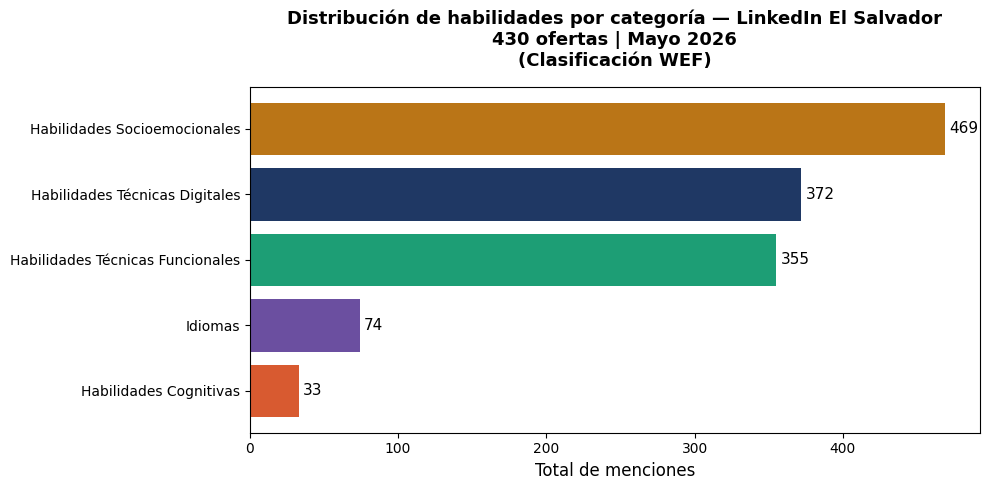

Gráfico guardado como categorias_wef.png


In [90]:
categorias = {
    "Habilidades Técnicas Digitales": [
        "Excel / Hojas de cálculo", "SQL / Bases de datos", "Power BI / Tableau",
        "Python / Programación", "Análisis de datos", "Inteligencia Artificial / IA",
        "SAP / ERP", "Office / Paquete Microsoft"
    ],
    "Habilidades Técnicas Funcionales": [
        "Contabilidad / Finanzas", "Ventas / CRM",
        "Logística / Supply Chain", "Marketing Digital", "Gestión de proyectos"
    ],
    "Habilidades Socioemocionales": [
        "Liderazgo", "Trabajo en equipo", "Comunicación",
        "Orientación al cliente", "Proactividad / Iniciativa"
    ],
    "Habilidades Cognitivas": [
        "Análisis de datos", "Resolución de problemas", "Gestión de proyectos"
    ],
    "Idiomas": [
        "Inglés"
    ],
}

df_freq['Categoría'] = df_freq['Habilidad'].apply(
    lambda h: next((cat for cat, habs in categorias.items() if h in habs), "Formación / Experiencia")
)

# Solo habilidades — excluir Formación y Experiencia
df_habilidades = df_freq[df_freq['Categoría'] != 'Formación / Experiencia']
totales = df_habilidades.groupby('Categoría')['Frecuencia'].sum().sort_values(ascending=True)

colores = {
    "Habilidades Técnicas Digitales": "#1F3864",
    "Habilidades Técnicas Funcionales": "#1D9E75",
    "Habilidades Socioemocionales": "#BA7517",
    "Habilidades Cognitivas": "#D85A30",
    "Idiomas": "#6B4FA0",
}

plt.figure(figsize=(10, 5))
bars = plt.barh(
    totales.index,
    totales.values,
    color=[colores[c] for c in totales.index]
)
plt.xlabel('Total de menciones', fontsize=12)
plt.title('Distribución de habilidades por categoría — LinkedIn El Salvador\n430 ofertas | Mayo 2026\n(Clasificación WEF)',
          fontsize=13, fontweight='bold', pad=15)

for bar, val in zip(bars, totales.values):
    plt.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('categorias_wef.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado como categorias_wef.png")